# Full scale flight data analysis pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import scipy.optimize as optimize
from matplotlib import gridspec 

# Setting up plotting style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 22
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['mathtext.fontset'] = 'cm'

Function to plot OpenRocket data

In [2]:
def openrocket_to_plot(file_path, code_to_run=None, **kwargs):
    # Reading in data
    df = pd.read_csv(file_path, comment='#')
    
    # Reading in events
    with open(file_path, 'r') as f:
        lines = f.readlines()
        event_lines = [line for line in lines if line.startswith('#')]

    # Extracting event names
    events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]

    # Extracting event times
    event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

    # Defining events to plot
    plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

    # Plotting flight profile
    fig = plt.figure()
    fig.set_tight_layout(kwargs.get('tight_layout', True))
    
    ax = fig.add_subplot()

    if code_to_run is not None:
        exec(code_to_run)

    elif kwargs.get('plot_type', 'altitude') == 'altitude':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft]')

    elif kwargs.get('plot_type') == 'velocity':
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Velocity [ft/s]')

    elif kwargs.get('plot_type') == 'acceleration':
        ax.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-'), color=kwargs.get('color', 'b'), label=kwargs.get('label', None), linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Acceleration [ft/s²]')

    elif kwargs.get('plot_type') == 'all':
        ax.plot(df['Time (s)'], df['Altitude (ft)'], linestyle=kwargs.get('linestyle', '-'), color='b', label='Altitude', linewidth=kwargs.get('linewidth', 2))
        ax.plot(df['Time (s)'], df['Total velocity (ft/s)'], linestyle=kwargs.get('linestyle', '--'), color='r', label='Velocity', linewidth=kwargs.get('linewidth', 2))
        ax.set_ylabel('Altitude [ft], Velocity [ft/s]')

        ax2 = ax.twinx()
        ax2.plot(df['Time (s)'], df['Total acceleration (ft/s²)'], linestyle=kwargs.get('linestyle', '-.'), color='g', label='Acceleration', linewidth=kwargs.get('linewidth', 2))
        ax2.set_ylabel('Acceleration [ft/s²]')

    drogue_deployed = False
    pilot_deployment = False
    for event, event_time in zip(events, event_times):
        if event in plot_events:
            ax.axvline(event_time, linestyle='--', color='k')

            if event == 'RECOVERY_DEVICE_DEPLOYMENT':
                if not drogue_deployed:
                    # Label on right side near middle
                    event_label = 'Drogue Deployment'
                    drogue_deployed = True
                    ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
                elif not pilot_deployment:
                    # Label on left side near top
                    event_label = 'Pilot Deployment'
                    ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
                    pilot_deployment = True
                else:
                    event_label = 'Main Deployment'
                    ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
                    main_deployment = True

            elif event == 'BURNOUT':
                # Label on right side near top
                ax.text(event_time + 0.5, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)

            elif event == 'APOGEE' or event == 'GROUND_HIT':
                # Label on left side near middle
                ax.text(event_time - 0.3, np.mean(ax.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
            else:
                # Label on left side near top
                ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

    # fig.suptitle('Simulated Flight Profile', y=0.95)
    ax.set_xlabel('Time [s]')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    if kwargs.get('label', None) is not None: ax.legend(loc='upper right')

    if kwargs.get('plot_type') == 'all':
        return fig, ax, ax2
    return fig, ax
    

## Loading all three data files in

Reading in flight profile data from avionics, OpenRocket, and custom simulation

In [35]:
data_openrocket = pd.read_csv('OpenRocket Flight Data 3.csv', comment='#')
data_avionics_primary = pd.read_csv('Primary Flight Data 3.csv')
data_avionics_secondary = pd.read_csv('Secondary Flight Data 3.csv')
data_payload = pd.read_csv('Payload Flight Data 3.csv')

Creating copies of data frames with the same keys

In [37]:
data_openrocket2 = data_openrocket.assign(**{'Altitude [ft]': data_openrocket['Altitude (ft)'], 'Time [s]': data_openrocket['Time (s)'], 'Velocity [ft/s]': data_openrocket['Total velocity (ft/s)'], 'Acceleration [ft/s²]': data_openrocket['Total acceleration (ft/s²)']})
data_avionics_primary2 = data_avionics_primary.assign(**{'Altitude [ft]': data_avionics_primary['height'] * 3.28084, 'Time [s]': data_avionics_primary['time'], 'Acceleration [ft/s²]': data_avionics_primary['acceleration'] * 3.28084, 'Velocity [ft/s]': np.abs(data_avionics_primary['speed']) * 3.28084})
data_avionics_secondary2 = data_avionics_secondary.assign(**{'Altitude [ft]': data_avionics_secondary['height'] * 3.28084, 'Time [s]': data_avionics_secondary['time'] + 1, 'Acceleration [ft/s²]': data_avionics_secondary['acceleration'] * 3.28084, 'Velocity [ft/s]': np.abs(data_avionics_secondary['speed']) * 3.28084})
data_payload2 = data_payload.assign(**{
    'Altitude [ft]': (data_payload['Altitude [m]'] * 3.28084),
    'Time [s]': data_payload['Time [s]'] - data_payload['Time [s]'][0],
    'Acceleration [ft/s²]': 3.28084 * (data_payload['Linear Acceleration X [m/s^2]']**2 + data_payload['Linear Acceleration Y [m/s^2]']**2 + data_payload['Linear Acceleration Z [m/s^2]']**2)**0.5, 
})

data_payload2['Velocity [ft/s]'] = np.abs(np.gradient(data_payload2['Altitude [ft]'], data_payload2['Time [s]']))

data_avionics_primary2 = data_avionics_primary2[data_avionics_primary2['Time [s]'] <= 85]
data_avionics_secondary2 = data_avionics_secondary2[data_avionics_secondary2['Time [s]'] <= 85]

Defining launch day ground conditions

In [38]:
T_amb = 45 # [F]
P_amb = 99722 # [Pa]
T_amb = (T_amb - 32) * 5/9 + 273.15 # [K]
rho_amb = P_amb / (287.05 * T_amb) # [kg/m^3]
a_amb = np.sqrt(1.4 * 287.05 * T_amb) # [m/s]
print(f'Ambient Temperature: {T_amb:.2f} K')
print(f'Ambient Pressure: {P_amb:.2f} Pa')
print(f'Ambient Density: {rho_amb:.2f} kg/m^3')
print(f'Ambient Speed of Sound: {a_amb:.2f} m/s | {a_amb*3.28084:.2f} ft/s')

Ambient Temperature: 280.37 K
Ambient Pressure: 99722.00 Pa
Ambient Density: 1.24 kg/m^3
Ambient Speed of Sound: 335.67 m/s | 1101.27 ft/s


Calculating important flight parameters

In [90]:
# Apogee
print('==============================================')
apogee_openrocket = np.max(data_openrocket2['Altitude [ft]'])
apogee_avionics_primary = np.max(data_avionics_primary2['Altitude [ft]'])
apogee_avionics_secondary = np.max(data_avionics_secondary2['Altitude [ft]'])
apogee_payload = np.max(data_payload2['Altitude [ft]'])
print(f'Apogee (OpenRocket): {apogee_openrocket:.2f} ft')
print(f'Apogee (Primary Avionics): {apogee_avionics_primary:.2f} ft')
print(f'Apogee (Secondary Avionics): {apogee_avionics_secondary:.2f} ft')
print(f'Apogee (Payload): {apogee_payload:.2f} ft')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(apogee_openrocket - apogee_avionics_primary) / apogee_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(apogee_openrocket - apogee_avionics_secondary) / apogee_avionics_secondary:.2f}%')

# Time to Apogee
print('==============================================')
time_to_apogee_openrocket = data_openrocket2['Time [s]'][np.argmax(data_openrocket2['Altitude [ft]'])]
time_to_apogee_avionics_primary = data_avionics_primary2['Time [s]'][np.argmax(data_avionics_primary2['Altitude [ft]'])]
time_to_apogee_avionics_secondary = data_avionics_secondary2['Time [s]'][np.argmax(data_avionics_secondary2['Altitude [ft]'])]
time_to_apogee_payload = data_payload2['Time [s]'][np.argmax(data_payload2['Altitude [ft]'])]
print(f'Time to Apogee (OpenRocket): {time_to_apogee_openrocket:.2f} s')
print(f'Time to Apogee (Primary Avionics): {time_to_apogee_avionics_primary:.2f} s')
print(f'Time to Apogee (Secondary Avionics): {time_to_apogee_avionics_secondary:.2f} s')
print(f'Time to Apogee (Payload): {time_to_apogee_payload:.2f} s')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(time_to_apogee_openrocket - time_to_apogee_avionics_primary) / time_to_apogee_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(time_to_apogee_openrocket - time_to_apogee_avionics_secondary) / time_to_apogee_avionics_secondary:.2f}%')

# Maximum velocity
print('==============================================')
max_velocity_openrocket = np.max(data_openrocket2['Velocity [ft/s]'])
max_velocity_avionics_primary = np.max(data_avionics_primary2['Velocity [ft/s]'])
max_velocity_avionics_secondary = np.max(data_avionics_secondary2['Velocity [ft/s]'])
max_velocity_payload = np.max(data_payload2['Velocity [ft/s]'])
print(f'Maximum Velocity (OpenRocket): {max_velocity_openrocket:.2f} ft/s | {max_velocity_openrocket/a_amb/3.28084:.2f} M')
print(f'Maximum Velocity (Primary Avionics): {max_velocity_avionics_primary:.2f} ft/s | {max_velocity_avionics_primary/a_amb/3.28084:.2f} M')
print(f'Maximum Velocity (Secondary Avionics): {max_velocity_avionics_secondary:.2f} ft/s | {max_velocity_avionics_secondary/a_amb/3.28084:.2f} M')
print(f'Maximum Velocity (Payload): {max_velocity_payload:.2f} ft/s | {max_velocity_payload/a_amb/3.28084:.2f} M')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(max_velocity_openrocket - max_velocity_avionics_primary) / max_velocity_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(max_velocity_openrocket - max_velocity_avionics_secondary) / max_velocity_avionics_secondary:.2f}%')
print(f'Percent error between Primary Avionics and Secondary Avionics: {100 * abs(max_velocity_avionics_primary - max_velocity_avionics_secondary) / max_velocity_avionics_secondary:.2f}%')
print(f'Percent error between OpenRocket and Payload: {100 * abs(max_velocity_openrocket - max_velocity_payload) / max_velocity_payload:.2f}%')

# Flight time
print('==============================================')
flight_time_openrocket = data_openrocket2['Time [s]'][np.argmax(data_openrocket2['Time [s]'])]
flight_time_avionics_primary = data_avionics_primary2['Time [s]'][np.argmax(data_avionics_primary2['Time [s]'])]
flight_time_avionics_secondary = data_avionics_secondary2['Time [s]'][np.argmax(data_avionics_secondary2['Time [s]'])]
print(f'Flight Time (OpenRocket): {flight_time_openrocket:.2f} s')
print(f'Flight Time (Primary Avionics): {flight_time_avionics_primary:.2f} s')
print(f'Flight Time (Secondary Avionics): {flight_time_avionics_secondary:.2f} s')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(flight_time_openrocket - flight_time_avionics_primary) / flight_time_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(flight_time_openrocket - flight_time_avionics_secondary) / flight_time_avionics_secondary:.2f}%')
print(f'Percent error between Primary Avionics and Secondary Avionics: {100 * abs(flight_time_avionics_primary - flight_time_avionics_secondary) / flight_time_avionics_secondary:.2f}%')

# Descent time
print('==============================================')
descent_time_openrocket = flight_time_openrocket - time_to_apogee_openrocket
descent_time_avionics_primary = flight_time_avionics_primary - time_to_apogee_avionics_primary
descent_time_avionics_secondary = flight_time_avionics_secondary - time_to_apogee_avionics_secondary
print(f'Descent Time (OpenRocket): {descent_time_openrocket:.2f} s')
print(f'Descent Time (Primary Avionics): {descent_time_avionics_primary:.2f} s')
print(f'Descent Time (Secondary Avionics): {descent_time_avionics_secondary:.2f} s')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(descent_time_openrocket - descent_time_avionics_primary) / descent_time_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(descent_time_openrocket - descent_time_avionics_secondary) / descent_time_avionics_secondary:.2f}%')
print(f'Percent error between Primary Avionics and Secondary Avionics: {100 * abs(descent_time_avionics_primary - descent_time_avionics_secondary) / descent_time_avionics_secondary:.2f}%')

# Maximum acceleration
print('==============================================')
max_acceleration_openrocket = np.max(data_openrocket2['Acceleration [ft/s²]'][data_openrocket2['Time [s]'] <= time_to_apogee_openrocket -10])
max_acceleration_avionics_primary = np.max(data_avionics_primary2['Acceleration [ft/s²]'][data_avionics_primary2['Time [s]'] <= time_to_apogee_avionics_primary -10])
max_acceleration_avionics_secondary = np.max(data_avionics_secondary2['Acceleration [ft/s²]'][data_avionics_secondary2['Time [s]'] <= time_to_apogee_avionics_secondary -10])
print(f'Maximum Acceleration (OpenRocket): {max_acceleration_openrocket:.2f} ft/s² | {max_acceleration_openrocket/9.81:.2f} g')
print(f'Maximum Acceleration (Primary Avionics): {max_acceleration_avionics_primary:.2f} ft/s² | {max_acceleration_avionics_primary/9.81:.2f} g')
print(f'Maximum Acceleration (Secondary Avionics): {max_acceleration_avionics_secondary:.2f} ft/s² | {max_acceleration_avionics_secondary/9.81:.2f} g')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(max_acceleration_openrocket - max_acceleration_avionics_primary) / max_acceleration_avionics_primary:.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(max_acceleration_openrocket - max_acceleration_avionics_secondary) / max_acceleration_avionics_secondary:.2f}%')
print(f'Percent error between Primary Avionics and Secondary Avionics: {100 * abs(max_acceleration_avionics_primary - max_acceleration_avionics_secondary) / max_acceleration_avionics_secondary:.2f}%')

Apogee (OpenRocket): 4687.12 ft
Apogee (Primary Avionics): 4677.20 ft
Apogee (Secondary Avionics): 4682.35 ft
Apogee (Payload): 4706.82 ft
Percent error between OpenRocket and Primary Avionics: 0.21%
Percent error between OpenRocket and Secondary Avionics: 0.10%
Time to Apogee (OpenRocket): 17.05 s
Time to Apogee (Primary Avionics): 17.21 s
Time to Apogee (Secondary Avionics): 17.22 s
Time to Apogee (Payload): 17.22 s
Percent error between OpenRocket and Primary Avionics: 0.92%
Percent error between OpenRocket and Secondary Avionics: 0.98%
Maximum Velocity (OpenRocket): 620.93 ft/s | 0.56 M
Maximum Velocity (Primary Avionics): 590.81 ft/s | 0.54 M
Maximum Velocity (Secondary Avionics): 550.82 ft/s | 0.50 M
Maximum Velocity (Payload): 871.92 ft/s | 0.79 M
Percent error between OpenRocket and Primary Avionics: 5.10%
Percent error between OpenRocket and Secondary Avionics: 12.73%
Percent error between Primary Avionics and Secondary Avionics: 7.26%
Percent error between OpenRocket and Payl

## Plotting individual flights

Plotting OpenRocket flight profile

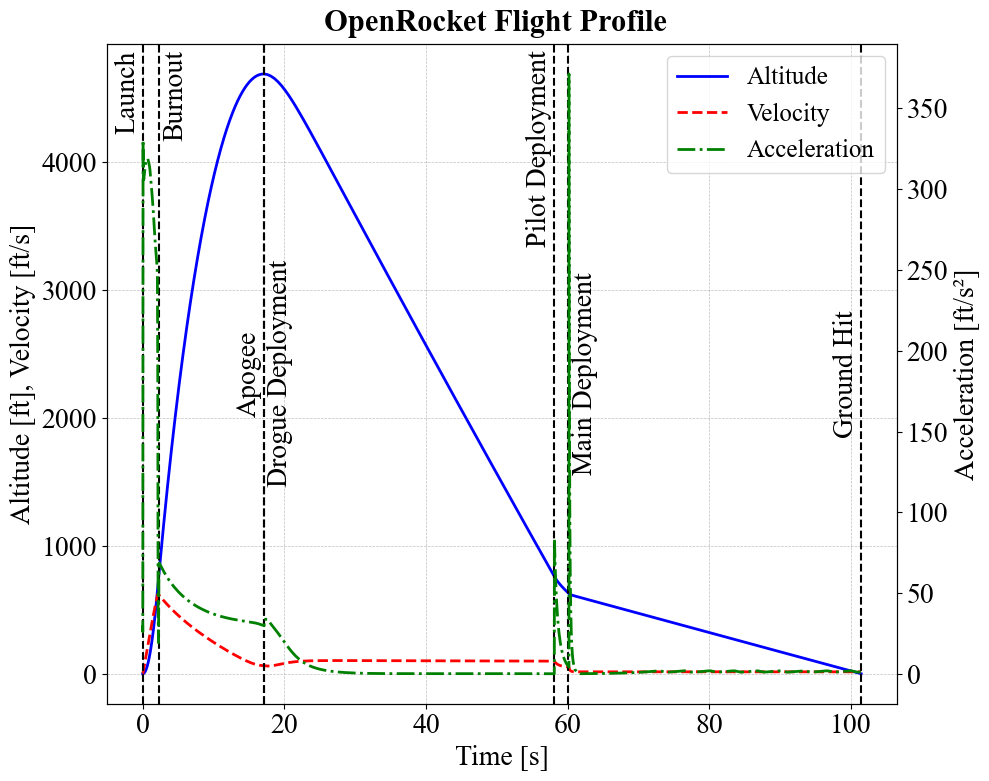

In [40]:
fig, ax1, ax2 = openrocket_to_plot('OpenRocket Flight Data 3.csv', plot_type='all')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(h1 + h2, l1 + l2, loc='upper right')
fig.suptitle('OpenRocket Flight Profile', y=0.97)

# fig.savefig('OpenRocket Full Scale Flight Profile.png', dpi=300)

plt.show()

Plotting avionics flight profile

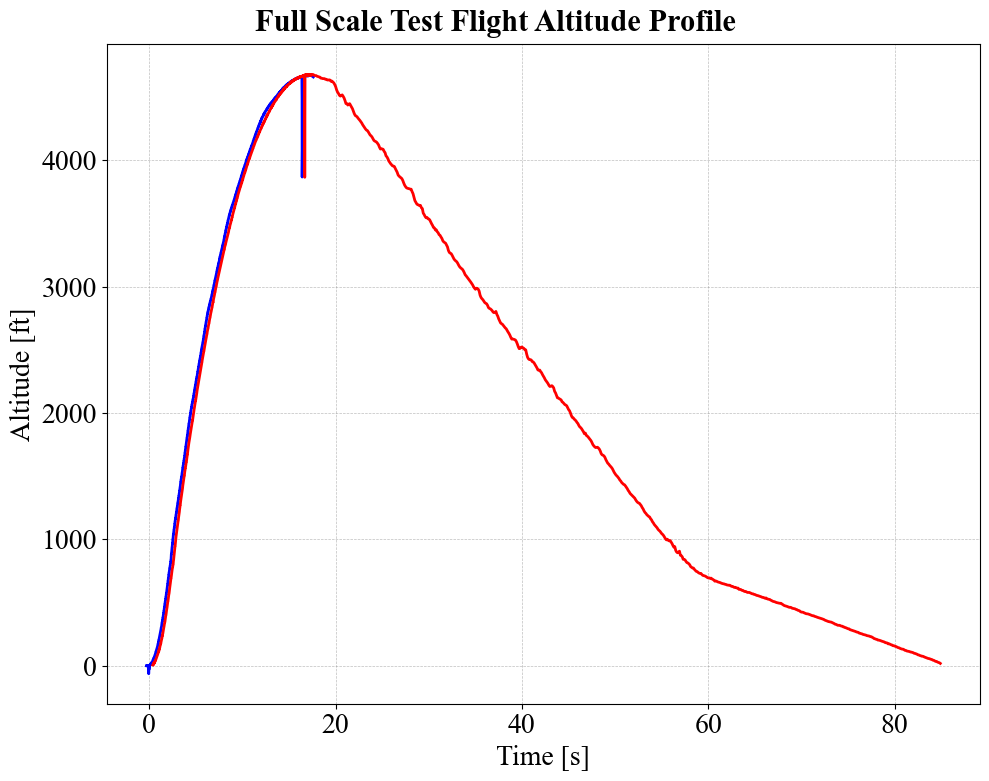

In [41]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Altitude [ft]'], linestyle='-', color='b', label='Primary Avionics', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='-', color='r', label='Secondary Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Altitude Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Altitude Profile.png', dpi=300)

plt.show()

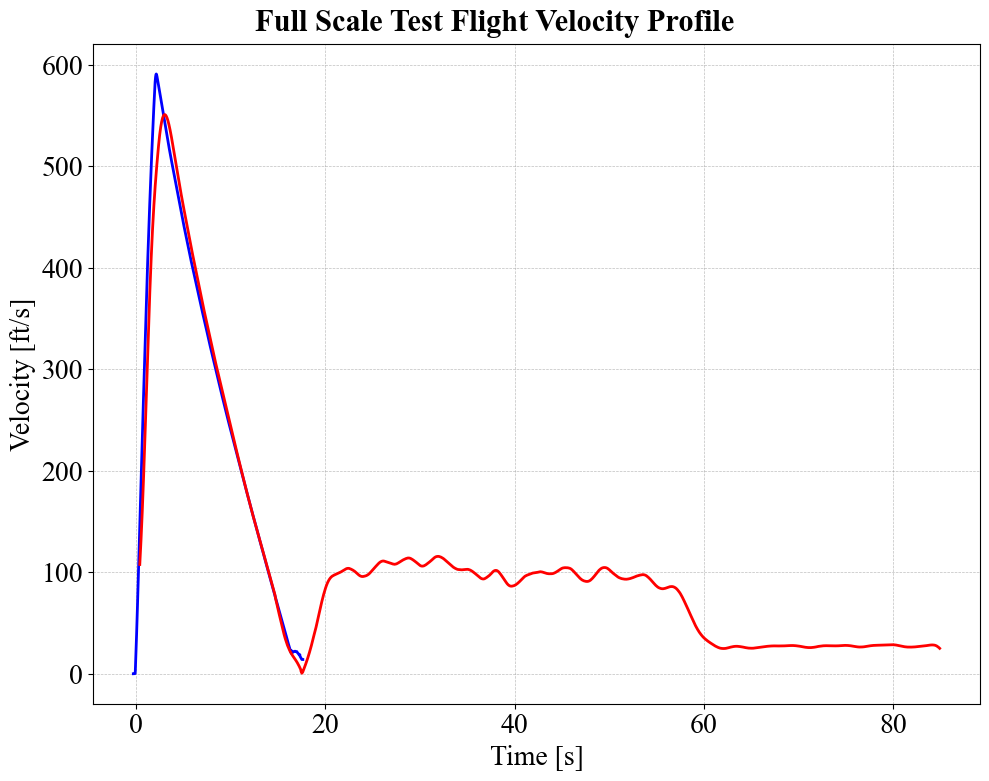

In [42]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Velocity [ft/s]'], linestyle='-', color='b', label='Primary Avionics', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='-', color='r', label='Secondary Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Velocity Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Profile.png', dpi=300)

plt.show()

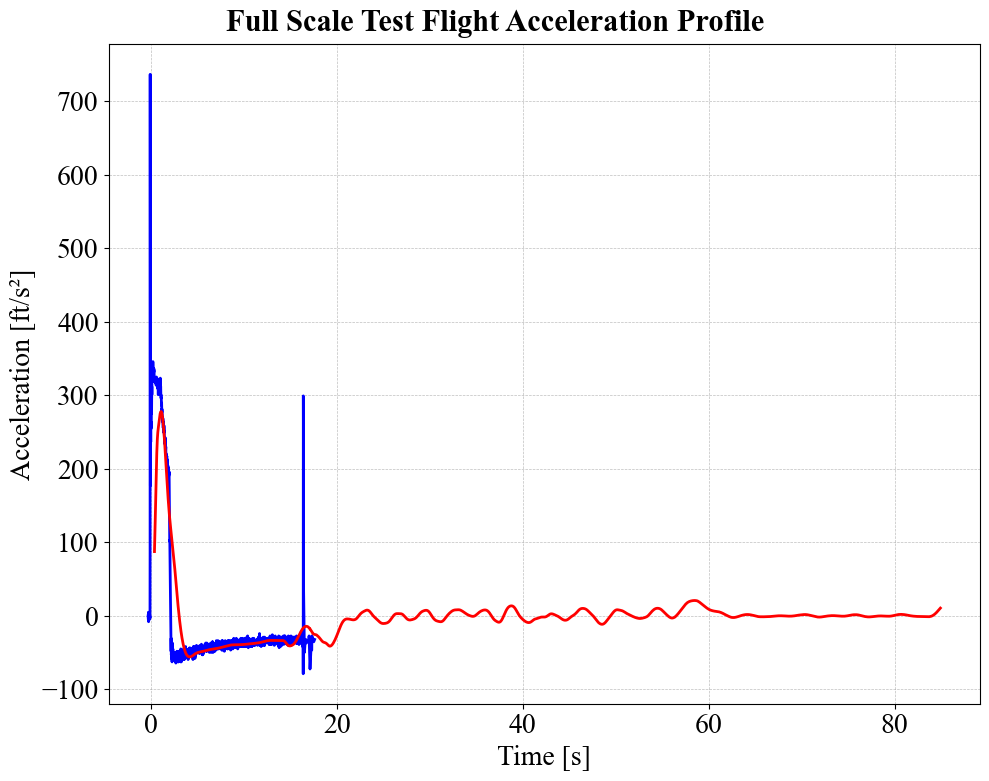

In [43]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Acceleration [ft/s²]'], linestyle='-', color='b', label='Primary Avionics', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Acceleration [ft/s²]'], linestyle='-', color='r', label='Secondary Avionics', linewidth=2)

fig.suptitle('Full Scale Test Flight Acceleration Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration [ft/s²]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Test Flight Profile.png', dpi=300)

plt.show()

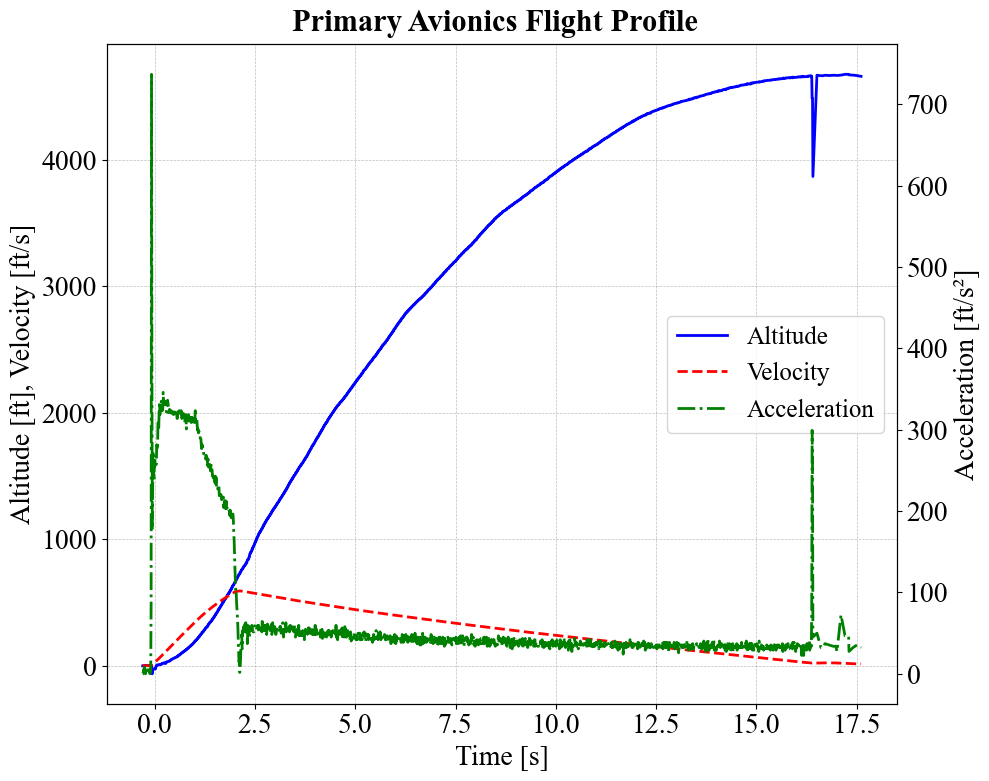

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_avionics_primary2['Time [s]'], np.abs(data_avionics_primary2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_avionics_primary2['Time [s]'], np.abs(data_avionics_primary2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Primary Avionics Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')

# fig.savefig('Primary Avionics Flight Profile.png', dpi=300)

plt.show()

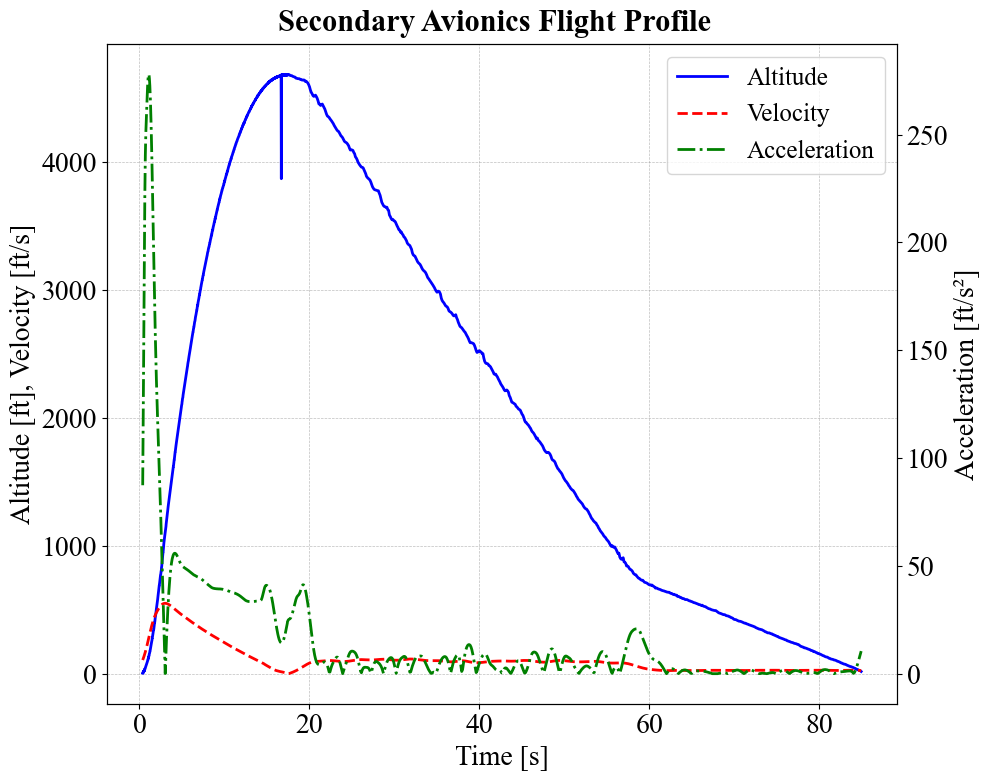

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Secondary Avionics Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

# fig.savefig('Secondary Avionics Flight Profile.png', dpi=300)

plt.show()

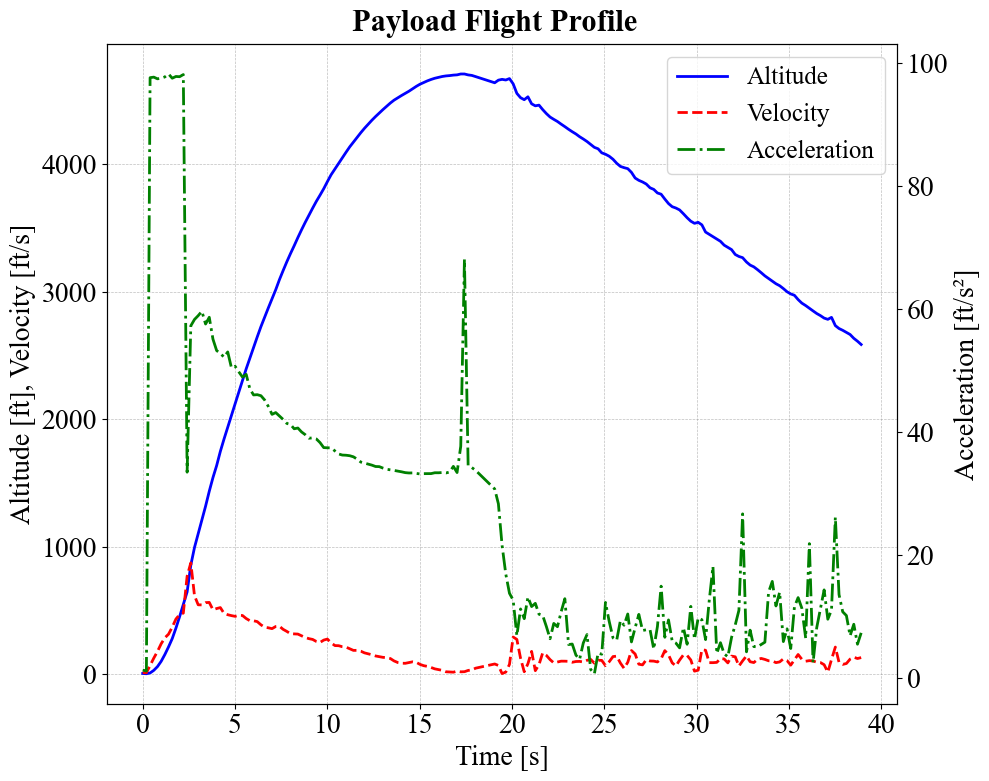

In [ ]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(data_payload2['Time [s]'], np.abs(data_payload2['Velocity [ft/s]']), linestyle='--', color='r', label='Velocity', linewidth=2)

ax2 = ax.twinx()
ax2.plot(data_payload2['Time [s]'], np.abs(data_payload2['Acceleration [ft/s²]']), linestyle='-.', color='g', label='Acceleration', linewidth=2)

fig.suptitle('Payload Flight Profile', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft], Velocity [ft/s]')
ax2.set_ylabel('Acceleration [ft/s²]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper right')

# fig.savefig('Payload Flight Profile.png', dpi=300)

plt.show()

## Comparison plots

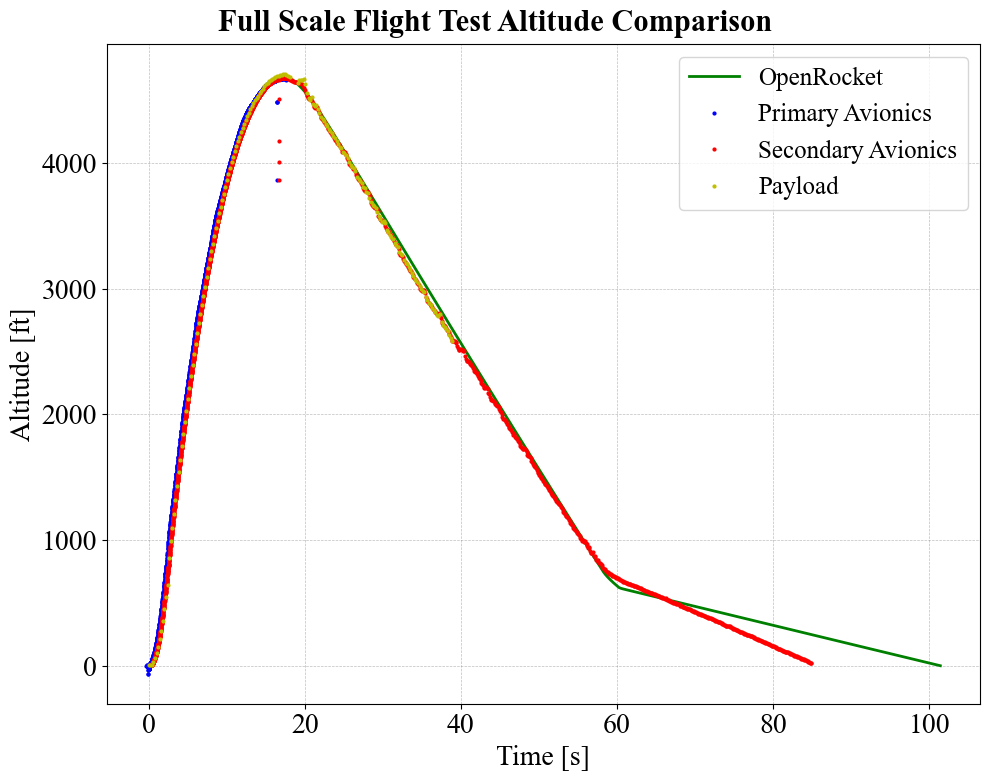

In [48]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Altitude [ft]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Primary Avionics', markersize=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='None', marker='o', color='r', label='Secondary Avionics', markersize=2)
ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='None', marker='o', color='y', label='Payload', markersize=2)

fig.suptitle('Full Scale Flight Test Altitude Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

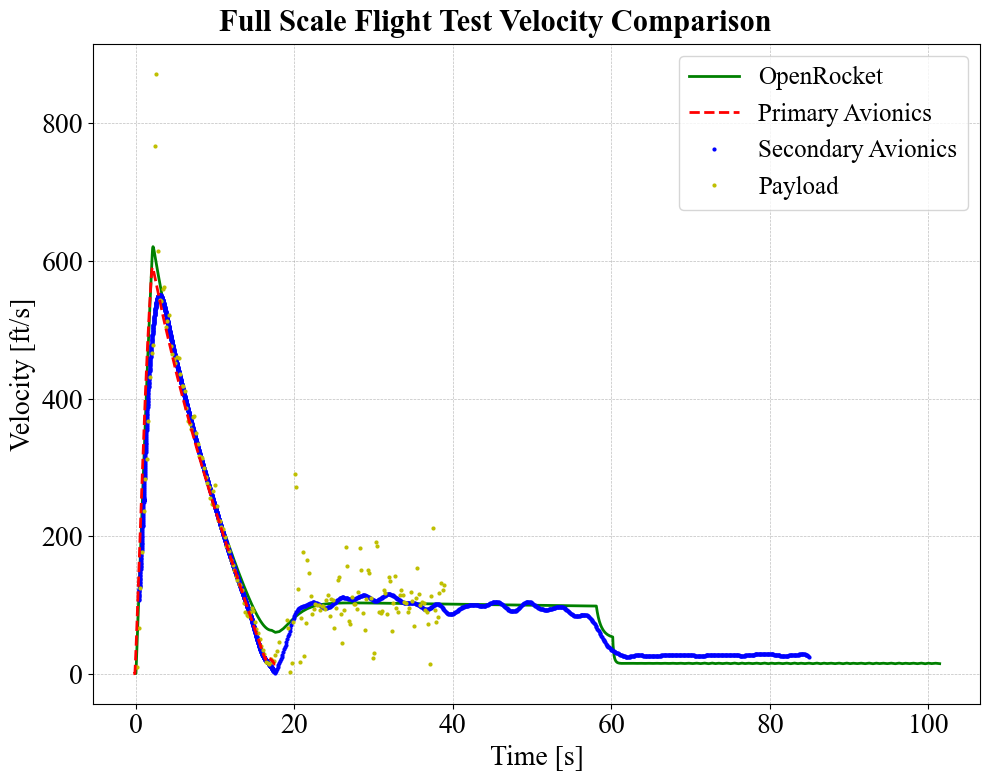

In [49]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the velocity comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Velocity [ft/s]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Velocity [ft/s]'], linestyle='--', color='r', label='Primary Avionics', linewidth=2, zorder=5)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', label='Secondary Avionics', markersize=2)
ax.plot(data_payload2['Time [s]'], data_payload2['Velocity [ft/s]'], linestyle='None', marker='o', color='y', label='Payload', markersize=2)

fig.suptitle('Full Scale Flight Test Velocity Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

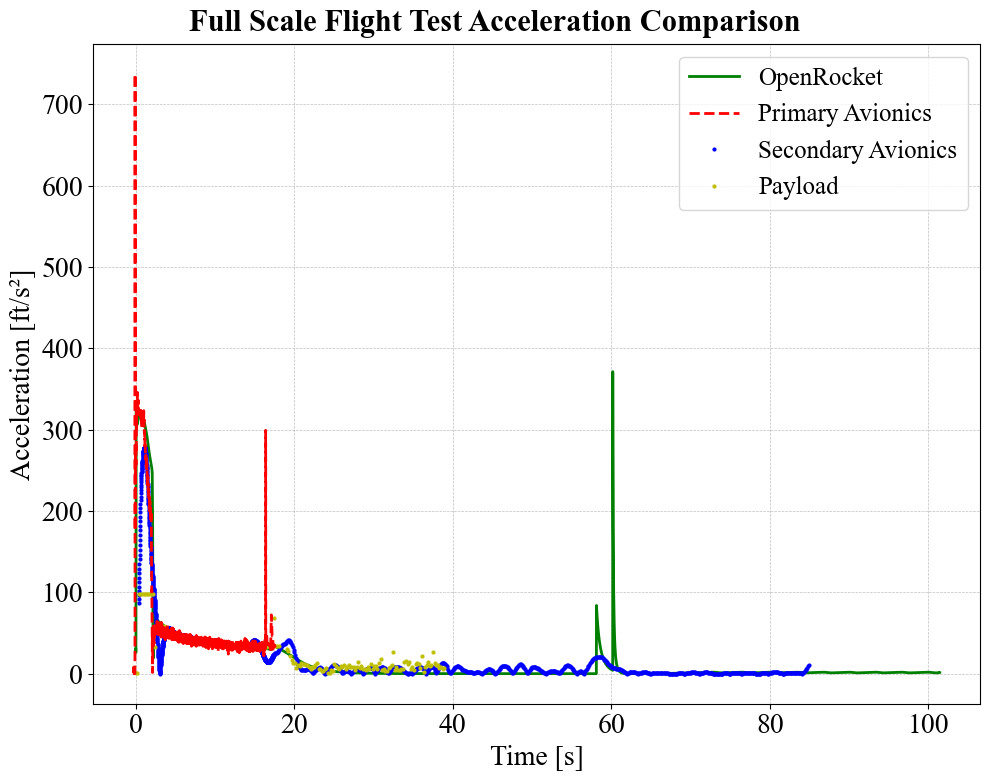

In [51]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

# Plotting the acceleration comparison plots between OpenRocket, custom simulation, and avionics
ax.plot(data_openrocket2['Time [s]'], data_openrocket2['Acceleration [ft/s²]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax.plot(data_avionics_primary2['Time [s]'], np.abs(data_avionics_primary2['Acceleration [ft/s²]']), linestyle='--', color='r', label='Primary Avionics', linewidth=2, zorder=5)
ax.plot(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', label='Secondary Avionics', markersize=2)
ax.plot(data_payload2['Time [s]'], np.abs(data_payload2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='y', label='Payload', markersize=2)

fig.suptitle('Full Scale Flight Test Acceleration Comparison', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration [ft/s²]')
ax.legend(loc='upper right')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# fig.savefig('Full Scale Flight Comparison.png', dpi=300)
plt.show()

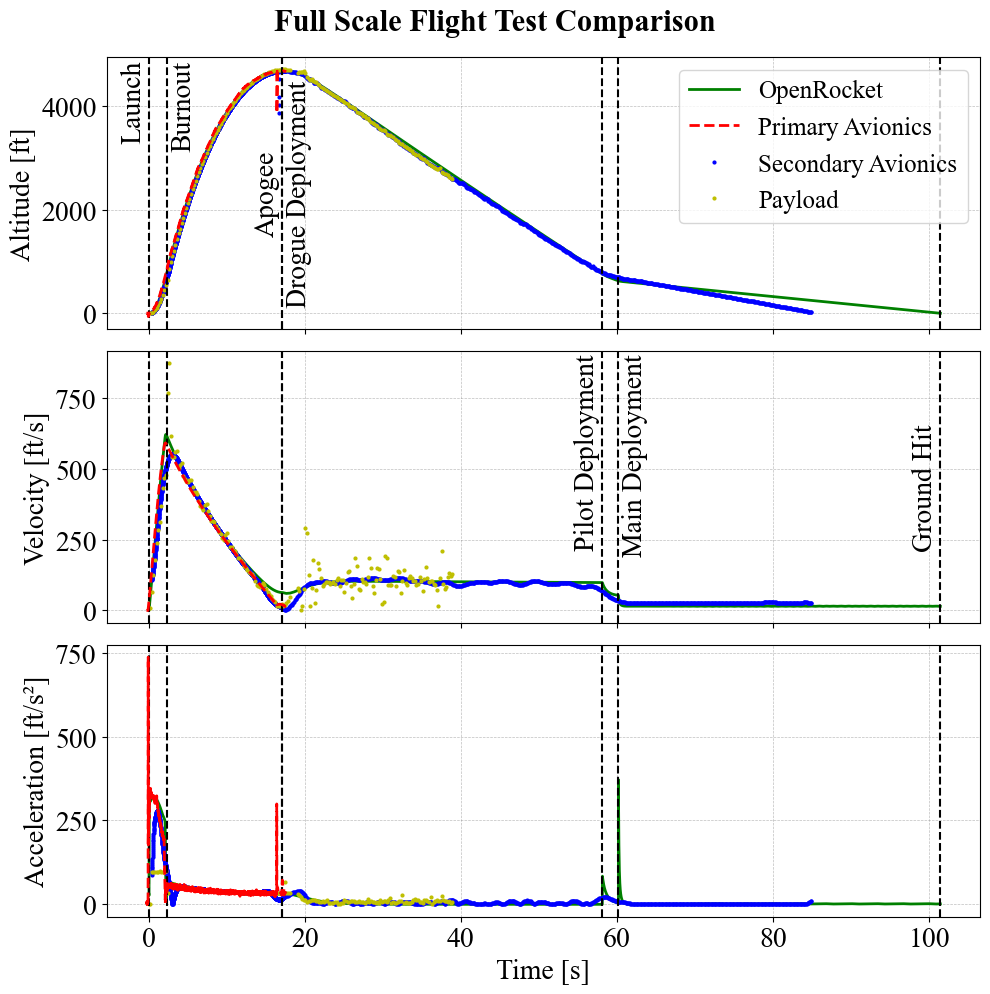

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.set_tight_layout(True)

# Altitude comparison
ax1.plot(data_openrocket2['Time [s]'], data_openrocket2['Altitude [ft]'], linestyle='-', color='g', label='OpenRocket', linewidth=2)
ax1.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Altitude [ft]'], linestyle='--', color='r', label='Primary Avionics', linewidth=2, zorder=5)
ax1.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Secondary Avionics', markersize=2)
ax1.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='None', marker='o', color='y', label='Payload', markersize=2)
ax1.set_ylabel('Altitude [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity comparison
ax2.plot(data_openrocket2['Time [s]'], data_openrocket2['Velocity [ft/s]'], linestyle='-', color='g', linewidth=2)
ax2.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['Velocity [ft/s]'], linestyle='--', color='r', linewidth=2, zorder=5)
ax2.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', markersize=2)
ax2.plot(data_payload2['Time [s]'], data_payload2['Velocity [ft/s]'], linestyle='None', marker='o', color='y', markersize=2)
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration comparison
ax3.plot(data_openrocket2['Time [s]'], data_openrocket2['Acceleration [ft/s²]'], linestyle='-', color='g', linewidth=2)
ax3.plot(data_avionics_primary2['Time [s]'], np.abs(data_avionics_primary2['Acceleration [ft/s²]']), linestyle='--', color='r', linewidth=2, zorder=5)
ax3.plot(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', markersize=2)
ax3.plot(data_payload2['Time [s]'], np.abs(data_payload2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='y', markersize=2)
ax3.set_ylabel('Acceleration [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Single legend for all three subplots (from first subplot's labels)
ax1.legend(loc='upper right')

# Adding vertical lines for important flight events, from OpenRocket file
with open('OpenRocket Flight Data 3.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

# drogue_deployed = False
# pilot_deployment = False
# for event, event_time in zip(events, event_times):
#     if event in plot_events:
#         ax.axvline(event_time, linestyle='--', color='k')

#         if event == 'RECOVERY_DEVICE_DEPLOYMENT':
#             if not drogue_deployed:
#                 # Label on right side near middle
#                 event_label = 'Drogue Deployment'
#                 drogue_deployed = True
#                 ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
#             elif not pilot_deployment:
#                 # Label on left side near top
#                 event_label = 'Pilot Deployment'
#                 ax.text(event_time - 0.3, 0.99 * ax.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
#                 pilot_deployment = True
#             else:
#                 event_label = 'Main Deployment'
#                 ax.text(event_time + 0.5, np.mean(ax.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
#                 main_deployment = True

drogue_deployed = False
pilot_deployment = False
for event, event_time in zip(events, event_times):
    if event in plot_events:
        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                event_label = 'Drogue Deployment'
                drogue_deployed = True
                ax1.text(event_time + 0.5, np.mean(ax1.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
            elif not pilot_deployment:
                event_label = 'Pilot Deployment'
                ax2.text(event_time - 0.3, 0.99 * ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
                pilot_deployment = True
            else:
                event_label = 'Main Deployment'
                ax2.text(event_time + 0.5, 0.99*ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
                main_deployment = True

        elif event == 'BURNOUT':
            ax1.text(event_time + 0.5, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.3, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        elif event == 'GROUND_HIT':
            ax2.text(event_time - 0.3, np.mean(ax2.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        else:
            ax1.text(event_time - 0.3, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

fig.suptitle('Full Scale Flight Test Comparison', y=0.99)

# fig.savefig('Full Scale Flight Test Comparison.png', dpi=300)

plt.show()

## Analyzing descent

In [55]:
# Drogue parachute fit
drogue_descent_velocities_avionics_primary = data_avionics_primary2['Velocity [ft/s]'][(data_avionics_primary2['Time [s]'] > 30) & (data_avionics_primary2['Time [s]'] < 45)]
drogue_descent_velocities_avionics_secondary = data_avionics_secondary2['Velocity [ft/s]'][(data_avionics_secondary2['Time [s]'] > 30) & (data_avionics_secondary2['Time [s]'] < 45)]
drogue_descent_velocities_openrocket = data_openrocket2['Velocity [ft/s]'][(data_openrocket2['Time [s]'] > 30) & (data_openrocket2['Time [s]'] < 45)]
print(f'Drogue Descent Rate, Average (Primary Avionics): {np.mean(drogue_descent_velocities_avionics_primary):.2f} ft/s')
print(f'Drogue Descent Rate, Average (Secondary Avionics): {np.mean(drogue_descent_velocities_avionics_secondary):.2f} ft/s')
print(f'Drogue Descent Rate, Average (OpenRocket): {np.mean(drogue_descent_velocities_openrocket):.2f} ft/s')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(np.mean(drogue_descent_velocities_openrocket) - np.mean(drogue_descent_velocities_avionics_primary)) / np.mean(drogue_descent_velocities_avionics_primary):.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(np.mean(drogue_descent_velocities_openrocket) - np.mean(drogue_descent_velocities_avionics_secondary)) / np.mean(drogue_descent_velocities_avionics_secondary):.2f}%')

# Main parachute fit
main_descent_velocities_avionics_primary = data_avionics_primary2['Velocity [ft/s]'][(data_avionics_primary2['Time [s]'] > 60) & (data_avionics_primary2['Time [s]'] < 80)]
main_descent_velocities_avionics_secondary = data_avionics_secondary2['Velocity [ft/s]'][(data_avionics_secondary2['Time [s]'] > 60) & (data_avionics_secondary2['Time [s]'] < 80)]
main_descent_velocities_openrocket = data_openrocket2['Velocity [ft/s]'][(data_openrocket2['Time [s]'] > 60) & (data_openrocket2['Time [s]'] < 80)]
print(f'Main Descent Rate, Average (Primary Avionics): {np.mean(main_descent_velocities_avionics_primary):.2f} ft/s')
print(f'Main Descent Rate, Average (Secondary Avionics): {np.mean(main_descent_velocities_avionics_secondary):.2f} ft/s')
print(f'Main Descent Rate, Average (OpenRocket): {np.mean(main_descent_velocities_openrocket):.2f} ft/s')
print(f'Percent error between OpenRocket and Primary Avionics: {100 * abs(np.mean(main_descent_velocities_openrocket) - np.mean(main_descent_velocities_avionics_primary)) / np.mean(main_descent_velocities_avionics_primary):.2f}%')
print(f'Percent error between OpenRocket and Secondary Avionics: {100 * abs(np.mean(main_descent_velocities_openrocket) - np.mean(main_descent_velocities_avionics_secondary)) / np.mean(main_descent_velocities_avionics_secondary):.2f}%')


Drogue Descent Rate, Average (Primary Avionics): nan ft/s
Drogue Descent Rate, Average (Secondary Avionics): 100.61 ft/s
Drogue Descent Rate, Average (OpenRocket): 101.57 ft/s
Percent error between OpenRocket and Primary Avionics: nan%
Percent error between OpenRocket and Secondary Avionics: 0.96%
Main Descent Rate, Average (Primary Avionics): nan ft/s
Main Descent Rate, Average (Secondary Avionics): 27.19 ft/s
Main Descent Rate, Average (OpenRocket): 30.37 ft/s
Percent error between OpenRocket and Primary Avionics: nan%
Percent error between OpenRocket and Secondary Avionics: 11.68%


In [57]:
drogue_data_avionics_primary = data_avionics_primary2[(data_avionics_primary2['Time [s]'].values > 30) & (data_avionics_primary2['Time [s]'].values < 45)]
drogue_data_avionics_secondary = data_avionics_secondary2[(data_avionics_secondary2['Time [s]'].values > 30) & (data_avionics_secondary2['Time [s]'].values < 45)]
drogue_data_openrocket = data_openrocket2[(data_openrocket2['Time [s]'].values > 30) & (data_openrocket2['Time [s]'].values < 45)]

main_data_avionics_primary = data_avionics_primary2[(data_avionics_primary2['Time [s]'].values > 60) & (data_avionics_primary2['Time [s]'].values < 80)]
main_data_avionics_secondary = data_avionics_secondary2[(data_avionics_secondary2['Time [s]'].values > 60) & (data_avionics_secondary2['Time [s]'].values < 80)]
main_data_openrocket = data_openrocket2[(data_openrocket2['Time [s]'].values > 60) & (data_openrocket2['Time [s]'].values < 80)]

# Drogue parachute fit
# drogue_fit_avionics_primary = np.polyfit(drogue_data_avionics_primary['Time [s]'], drogue_data_avionics_primary['Altitude [ft]'], 1)
drogue_fit_avionics_secondary = np.polyfit(drogue_data_avionics_secondary['Time [s]'], drogue_data_avionics_secondary['Altitude [ft]'], 1)
drogue_fit_openrocket = np.polyfit(drogue_data_openrocket['Time [s]'], drogue_data_openrocket['Altitude [ft]'], 1)

# Main parachute fit
# main_fit_avionics_primary = np.polyfit(main_data_avionics_primary['Time [s]'], main_data_avionics_primary['Altitude [ft]'], 1)
main_fit_avionics_secondary = np.polyfit(main_data_avionics_secondary['Time [s]'], main_data_avionics_secondary['Altitude [ft]'], 1)
main_fit_openrocket = np.polyfit(main_data_openrocket['Time [s]'], main_data_openrocket['Altitude [ft]'], 1)

# print(f'Drogue Descent Rate, Slope (Primary Avionics): {drogue_fit_avionics_primary[0]:.2f} ft/s')
print(f'Drogue Descent Rate, Slope (Secondary Avionics): {drogue_fit_avionics_secondary[0]:.2f} ft/s')
print(f'Drogue Descent Rate, Slope (OpenRocket): {drogue_fit_openrocket[0]:.2f} ft/s')

# print(f'Main Descent Rate, Slope (Primary Avionics): {main_fit_avionics_primary[0]:.2f} ft/s')
print(f'Main Descent Rate, Slope (Secondary Avionics): {main_fit_avionics_secondary[0]:.2f} ft/s')
print(f'Main Descent Rate, Slope (OpenRocket): {main_fit_openrocket[0]:.2f} ft/s')

Drogue Descent Rate, Slope (Secondary Avionics): -98.93 ft/s
Drogue Descent Rate, Slope (OpenRocket): -101.57 ft/s
Main Descent Rate, Slope (Secondary Avionics): -26.89 ft/s
Main Descent Rate, Slope (OpenRocket): -15.30 ft/s


Showing the velocity fits

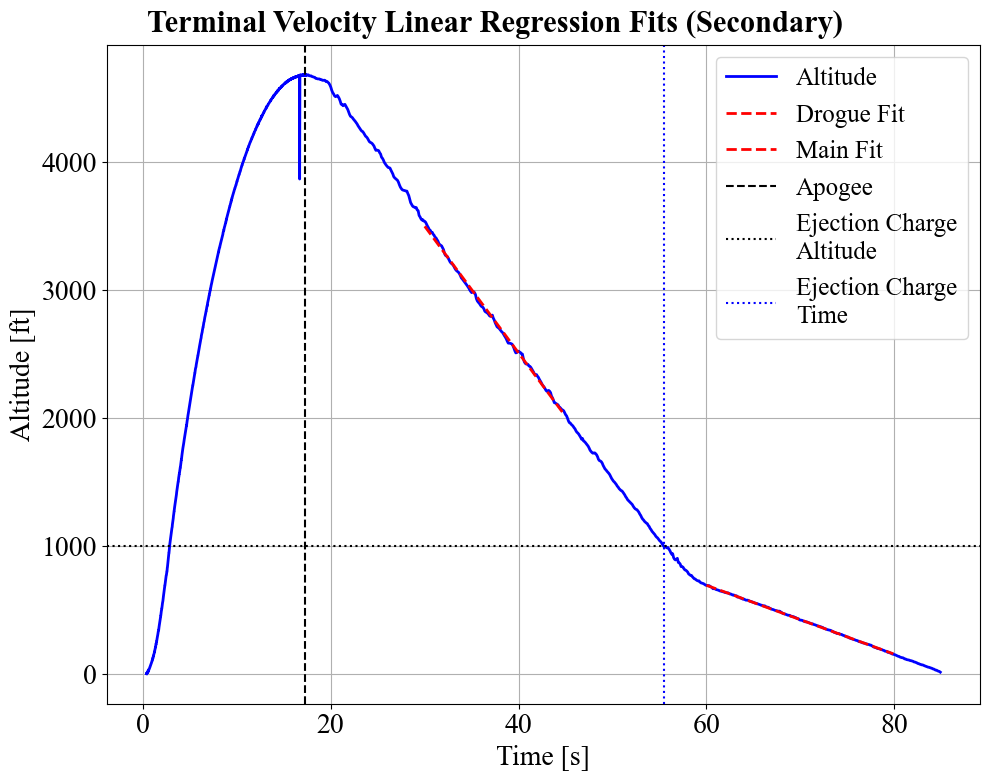

In [63]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)
ax.plot(drogue_data_avionics_secondary['Time [s]'], np.polyval(drogue_fit_avionics_secondary, drogue_data_avionics_secondary['Time [s]']), linestyle='--', color='r', linewidth=2, label='Drogue Fit')
ax.plot(main_data_avionics_secondary['Time [s]'], np.polyval(main_fit_avionics_secondary, main_data_avionics_secondary['Time [s]']), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax.axvline(time_to_apogee_avionics_secondary, color='k', linestyle='dashed', label='Apogee')
ax.axhline(1000, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax.axvline(55.5, color='b', linestyle=':', label='Ejection Charge\nTime')

fig.suptitle('Terminal Velocity Linear Regression Fits (Secondary)', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [ft]')
ax.grid(True)

ax.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits.png', dpi=300)

plt.show()

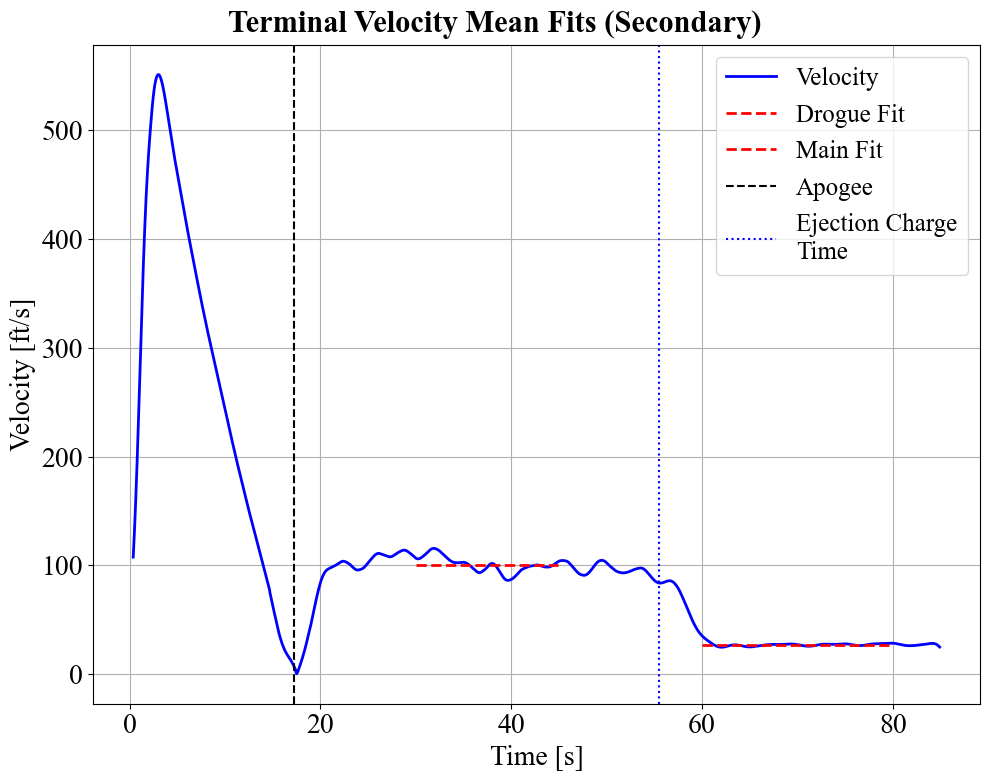

In [66]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='-', color='b', label='Velocity', linewidth=2)

ax.hlines(np.mean(drogue_data_avionics_secondary["Velocity [ft/s]"]), drogue_data_avionics_secondary['Time [s]'].min(), drogue_data_avionics_secondary['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax.hlines(np.mean(main_data_avionics_secondary["Velocity [ft/s]"]), main_data_avionics_secondary['Time [s]'].min(), main_data_avionics_secondary['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax.axvline(time_to_apogee_avionics_secondary, color='k', linestyle='dashed', label='Apogee')

ax.axvline(55.5, color='b', linestyle=':', label='Ejection Charge\nTime')

fig.suptitle('Terminal Velocity Mean Fits (Secondary)', y=0.97)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Velocity [ft/s]')
ax.grid(True)

ax.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits.png', dpi=300)

plt.show()

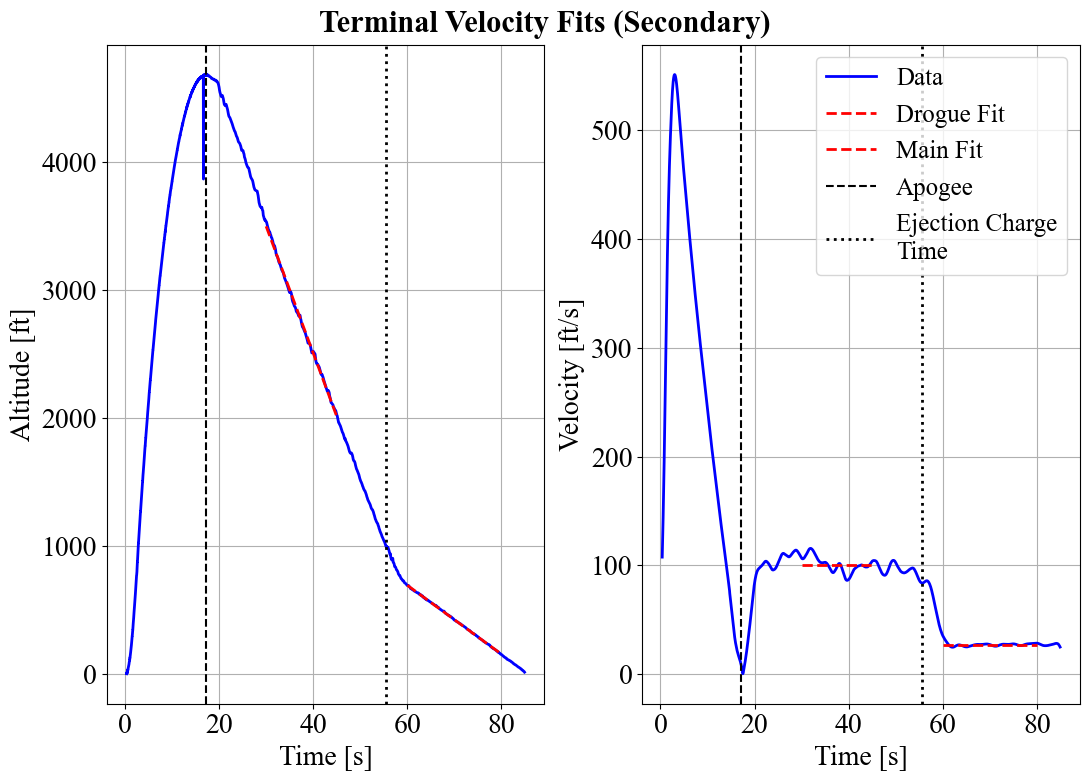

In [69]:
fig = plt.figure(figsize=(11, 8))
fig.set_tight_layout(True)
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='-', color='b', label='Altitude', linewidth=2)

ax1.plot(drogue_data_avionics_secondary['Time [s]'], np.polyval(drogue_fit_avionics_secondary, drogue_data_avionics_secondary['Time [s]']), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax1.plot(main_data_avionics_secondary['Time [s]'], np.polyval(main_fit_avionics_secondary, main_data_avionics_secondary['Time [s]']), linestyle='--', color='r', linewidth=2, label='Main Fit')

ax1.axvline(time_to_apogee_avionics_secondary, color='k', linestyle='dashed', label='Apogee')
# ax1.axhline(700, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax1.axvline(55.5, color='k', linestyle=':', label='Ejection Charge\nTime', linewidth=2)

fig.suptitle('Terminal Velocity Linear Regression Fits', y=0.97)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Altitude [ft]')
ax1.grid(True)

# ax1.legend(loc='upper right', ncol=1)

ax2.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='-', color='b', label='Data', linewidth=2)

ax2.hlines(np.mean(drogue_data_avionics_secondary["Velocity [ft/s]"]), drogue_data_avionics_secondary['Time [s]'].min(), drogue_data_avionics_secondary['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Drogue Fit')

ax2.hlines(np.mean(main_data_avionics_secondary["Velocity [ft/s]"]), main_data_avionics_secondary['Time [s]'].min(), main_data_avionics_secondary['Time [s]'].max(), linestyle='--', color='r', linewidth=2, label='Main Fit')
ax2.axvline(time_to_apogee_avionics_secondary, color='k', linestyle='dashed', label='Apogee')
# ax2.axhline(700, color='k', linestyle=':', label='Ejection Charge\nAltitude')

ax2.axvline(55.5, color='k', linestyle=':', label='Ejection Charge\nTime', linewidth=2)

fig.suptitle('Terminal Velocity Fits (Secondary)', y=0.97)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(True)

ax2.legend(loc='upper right', ncol=1)

# fig.savefig('Avionics Terminal Velocity Fits Combined.png', dpi=300)

plt.show()

## Seeing various conditions

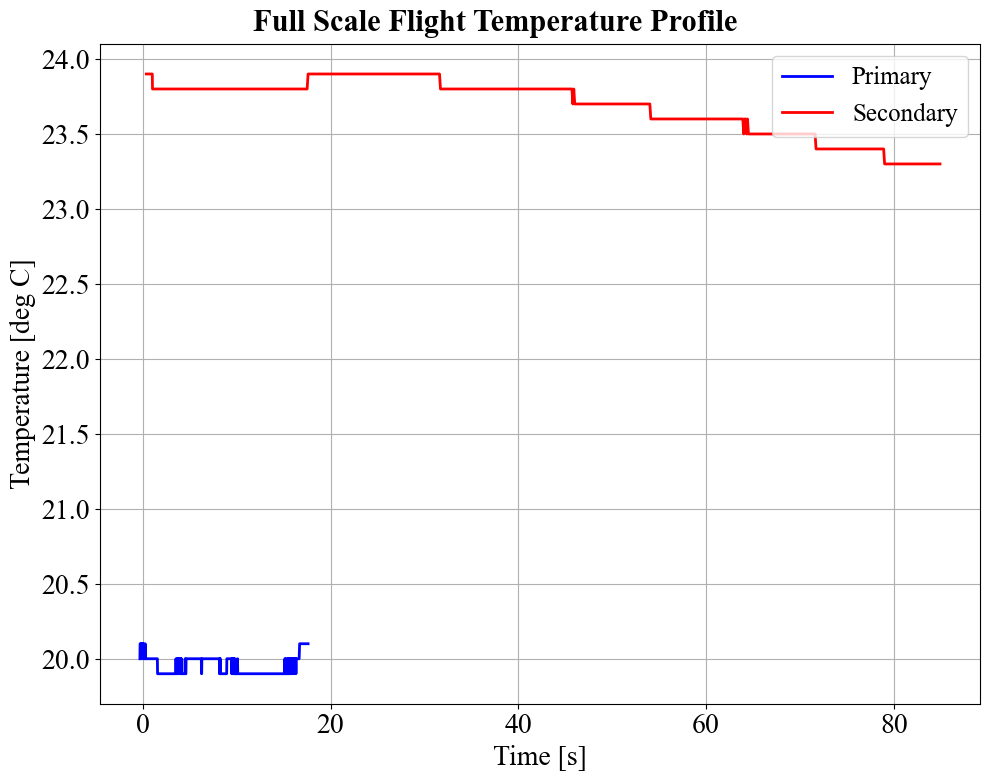

In [70]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Full Scale Flight Temperature Profile', y=0.97)

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['temperature'], linestyle='-', color='b', label='Primary', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['temperature'], linestyle='-', color='r', label='Secondary', linewidth=2)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Temperature [deg C]')
ax.grid(True)

ax.legend(loc='upper right')

plt.show()

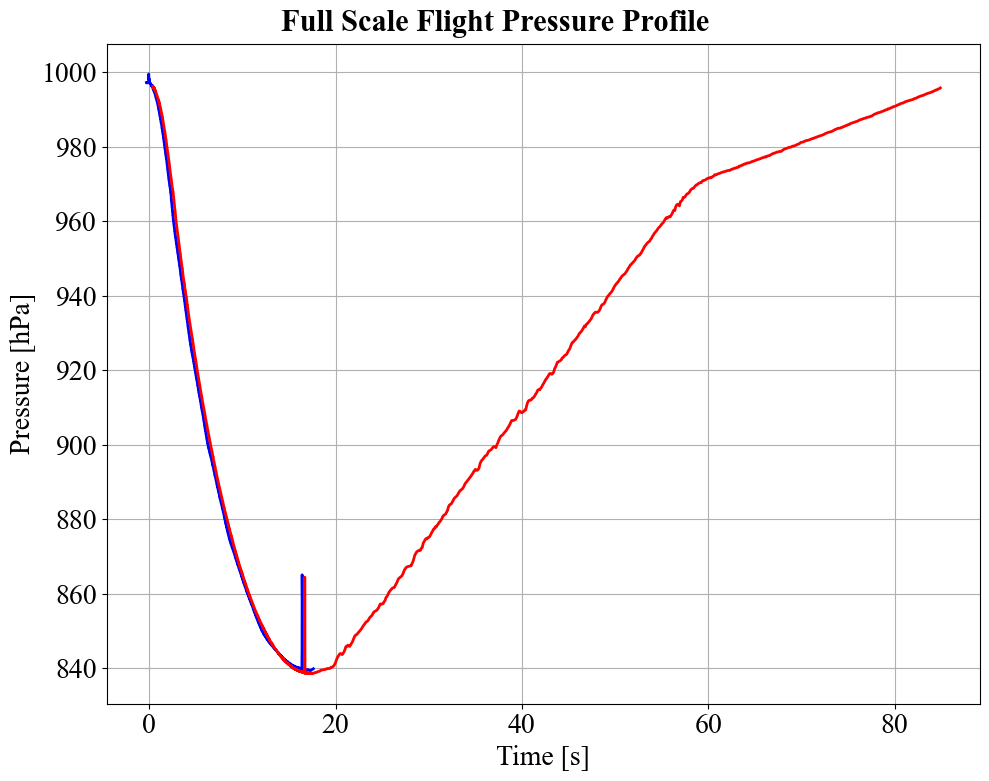

In [71]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Full Scale Flight Pressure Profile', y=0.97)

ax.plot(data_avionics_primary2['Time [s]'], data_avionics_primary2['pressure'] / 100, linestyle='-', color='b', label='Primary', linewidth=2)
ax.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['pressure'] / 100, linestyle='-', color='r', label='Secondary', linewidth=2)

ax.set_xlabel('Time [s]')
ax.set_ylabel('Pressure [hPa]')
ax.grid(True)

plt.show()

## Calculating $C_D$ from the descent data

Defining constants

In [74]:
T0 = 7.22 # deg C
P0 = 99722 # Pa

# Calculating density
R = 287.05 # J/(kg·K)
T_kelvin = T0 + 273.15 # Convert to Kelvin
rho0 = P0 / (R * T_kelvin) # kg/m^3

Drogue parachute descent

In [75]:
# velocity_drogue_avionics_primary = drogue_fit_avionics_primary[0]
velocity_drogue_avionics_secondary = drogue_fit_avionics_secondary[0]
velocity_drogue_openrocket = drogue_fit_openrocket[0]

# Calculating reference area
D_drogue = 24 # in
A_drogue = np.pi * (D_drogue * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

# Cd_drogue_avionics_primary = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics_primary * 0.3048)**2)
Cd_drogue_avionics_secondary = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics_secondary * 0.3048)**2)
Cd_drogue_openrocket = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_openrocket * 0.3048)**2)

# print(f'Drogue Parachute Drag Coefficient with Linear Regression (Primary): {Cd_drogue_avionics_primary:.2f}')
print(f'Drogue Parachute Drag Coefficient with Linear Regression (Secondary): {Cd_drogue_avionics_secondary:.2f}')
print(f'Drogue Parachute Drag Coefficient with Linear Regression (OpenRocket): {Cd_drogue_openrocket:.2f}')

Drogue Parachute Drag Coefficient with Linear Regression (Secondary): 1.26
Drogue Parachute Drag Coefficient with Linear Regression (OpenRocket): 1.19


In [77]:
velocity_drogue_avionics_primary = np.mean(drogue_data_avionics_primary["Velocity [ft/s]"])
velocity_drogue_avionics_secondary = np.mean(drogue_data_avionics_secondary["Velocity [ft/s]"])
velocity_drogue_openrocket = np.mean(drogue_data_openrocket["Velocity [ft/s]"])

# Calculating reference area
D_drogue = 24 # in
A_drogue = np.pi * (D_drogue * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_drogue_avionics_primary = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics_primary * 0.3048)**2)
Cd_drogue_avionics_secondary = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_avionics_secondary * 0.3048)**2)
Cd_drogue_openrocket = (2 * W_rocket) / (rho0 * A_drogue * (velocity_drogue_openrocket * 0.3048)**2)

print(f'Drogue Parachute Drag Coefficient with Velocity Averaging (Primary): {Cd_drogue_avionics_primary:.2f}')
print(f'Drogue Parachute Drag Coefficient with Velocity Averaging (Secondary): {Cd_drogue_avionics_secondary:.2f}')
print(f'Drogue Parachute Drag Coefficient with Velocity Averaging (OpenRocket): {Cd_drogue_openrocket:.2f}')

Drogue Parachute Drag Coefficient with Velocity Averaging (Primary): nan
Drogue Parachute Drag Coefficient with Velocity Averaging (Secondary): 1.22
Drogue Parachute Drag Coefficient with Velocity Averaging (OpenRocket): 1.19


Main parachute descent

In [78]:
# velocity_main_avionics_primary = main_fit_avionics_primary[0]
velocity_main_avionics_secondary = main_fit_avionics_secondary[0]
velocity_main_openrocket = main_fit_openrocket[0]

# Calculating reference area
D_main = 100 # in
A_main = np.pi * (D_main * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

# Cd_main_avionics_primary = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics_primary * 0.3048)**2)
Cd_main_avionics_secondary = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics_secondary * 0.3048)**2)
Cd_main_openrocket = (2 * W_rocket) / (rho0 * A_main * (velocity_main_openrocket * 0.3048)**2)

# print(f'Main Parachute Drag Coefficient with Linear Regression (Primary): {Cd_main_avionics_primary:.2f}')
print(f'Main Parachute Drag Coefficient with Linear Regression (Secondary): {Cd_main_avionics_secondary:.2f}')
print(f'Main Parachute Drag Coefficient with Linear Regression (OpenRocket): {Cd_main_openrocket:.2f}')

Main Parachute Drag Coefficient with Linear Regression (Secondary): 0.98
Main Parachute Drag Coefficient with Linear Regression (OpenRocket): 3.03


In [79]:
velocity_main_avionics_primary = np.mean(main_data_avionics_primary["Velocity [ft/s]"])
velocity_main_avionics_secondary = np.mean(main_data_avionics_secondary["Velocity [ft/s]"])
velocity_main_openrocket = np.mean(main_data_openrocket["Velocity [ft/s]"])

# Calculating reference area
D_main = 100 # in
A_main = np.pi * (D_main * 0.0254 / 2)**2 # m^2

# Weight of rocket
W_rocket = 21.092 * 9.81 # N

Cd_main_avionics_primary = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics_primary * 0.3048)**2)
Cd_main_avionics_secondary = (2 * W_rocket) / (rho0 * A_main * (velocity_main_avionics_secondary * 0.3048)**2)
Cd_main_openrocket = (2 * W_rocket) / (rho0 * A_main * (velocity_main_openrocket * 0.3048)**2)

print(f'Main Parachute Drag Coefficient with Velocity Averaging (Primary): {Cd_main_avionics_primary:.2f}')
print(f'Main Parachute Drag Coefficient with Velocity Averaging (Secondary): {Cd_main_avionics_secondary:.2f}')
print(f'Main Parachute Drag Coefficient with Velocity Averaging (OpenRocket): {Cd_main_openrocket:.2f}')

Main Parachute Drag Coefficient with Velocity Averaging (Primary): nan
Main Parachute Drag Coefficient with Velocity Averaging (Secondary): 0.96
Main Parachute Drag Coefficient with Velocity Averaging (OpenRocket): 0.77


## OpenRocket simulation plots with new $C_D$ values

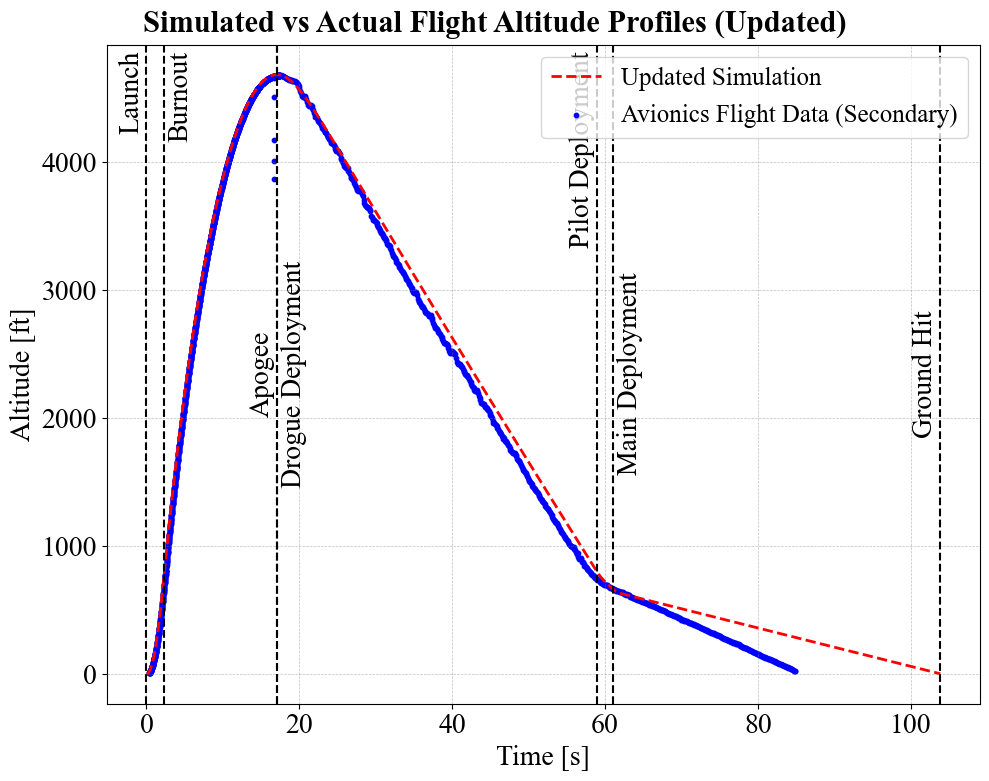

In [83]:
fig, ax = openrocket_to_plot('OpenRocket Flight Data 3 New.csv', color='r', label='Updated Simulation', linestyle='--')

ax.scatter(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], c='b', label='Avionics Flight Data (Secondary)', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Altitude Profiles (Updated)', y=0.97)

ax.legend(loc='upper right')

# fig.savefig('Simulated vs Actual Flight Altitude Profiles Updated.png', dpi=300)

plt.show()

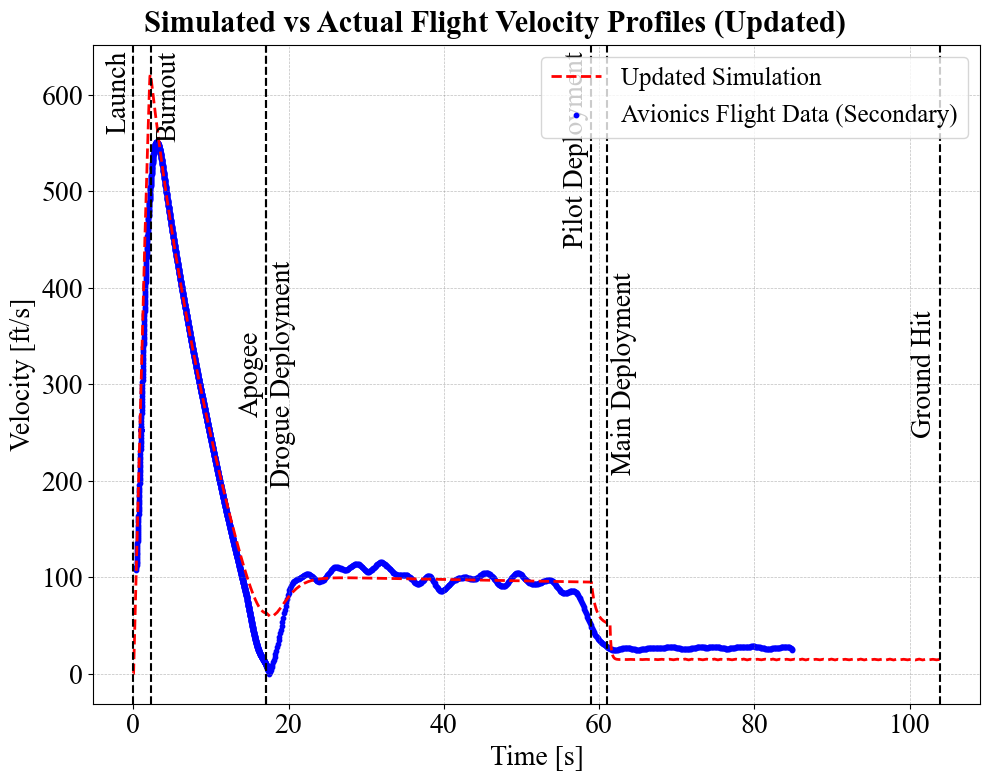

In [84]:
fig, ax = openrocket_to_plot('OpenRocket Flight Data 3 New.csv', color='r', label='Updated Simulation', linestyle='--', plot_type='velocity')

ax.scatter(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Velocity [ft/s]']), c='b', label='Avionics Flight Data (Secondary)', s=10)
# ax.plot(data_payload2['Time [s]'], data_payload2['Altitude [ft]'], linestyle='-', color='g', label='Payload Flight Data ', linewidth=2)

fig.suptitle('Simulated vs Actual Flight Velocity Profiles (Updated)', y=0.97)

ax.legend(loc='upper right')

# fig.savefig('Simulated vs Actual Flight Velocity Profiles Updated.png', dpi=300)

plt.show()

In [85]:
data_openrocket_new = pd.read_csv('OpenRocket Flight Data 3 New.csv', comment='#')
data_openrocket_new2 = data_openrocket_new.assign(**{'Altitude [ft]': data_openrocket_new['Altitude (ft)'], 'Time [s]': data_openrocket_new['Time (s)'], 'Velocity [ft/s]': data_openrocket_new['Total velocity (ft/s)'], 'Acceleration [ft/s²]': data_openrocket_new['Total acceleration (ft/s²)']})

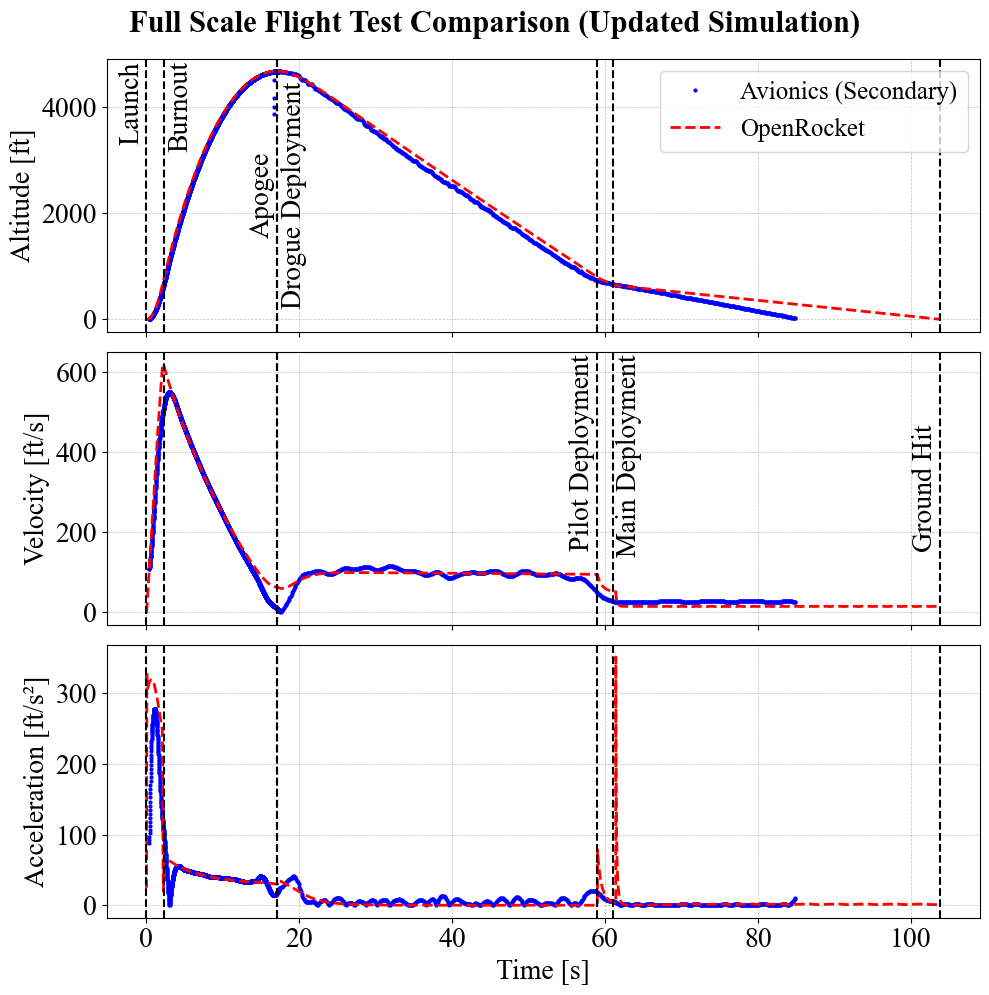

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.set_tight_layout(True)

# Altitude comparison
ax1.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Altitude [ft]'], linestyle='None', marker='o', color='b', label='Avionics (Secondary)', markersize=2)
ax1.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Altitude [ft]'], linestyle='--', color='r', label='OpenRocket', linewidth=2)
ax1.set_ylabel('Altitude [ft]')
ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Velocity comparison
ax2.plot(data_avionics_secondary2['Time [s]'], data_avionics_secondary2['Velocity [ft/s]'], linestyle='None', marker='o', color='b', markersize=2)
ax2.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Velocity [ft/s]'], linestyle='--', color='r', linewidth=2)
ax2.set_ylabel('Velocity [ft/s]')
ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Acceleration comparison
ax3.plot(data_avionics_secondary2['Time [s]'], np.abs(data_avionics_secondary2['Acceleration [ft/s²]']), linestyle='None', marker='o', color='b', markersize=2)
ax3.plot(data_openrocket_new2['Time [s]'], data_openrocket_new2['Acceleration [ft/s²]'], linestyle='--', color='r', linewidth=2)
ax3.set_ylabel('Acceleration [ft/s²]')
ax3.set_xlabel('Time [s]')
ax3.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Single legend for all three subplots (from first subplot's labels)
ax1.legend(loc='upper right')

# Adding vertical lines for important flight events, from OpenRocket file
with open('OpenRocket Flight Data 3 New.csv', 'r') as f:
    lines = f.readlines()
    event_lines = [line for line in lines if line.startswith('#') and 'Event' in line]

events = [line.split('Event ')[1].split(' occurred at t=')[0] for line in event_lines]
event_times = [float(line.split('t=')[1].split(' seconds')[0]) for line in event_lines]

plot_events = ['LAUNCH', 'BURNOUT', 'APOGEE', 'RECOVERY_DEVICE_DEPLOYMENT', 'GROUND_HIT']

drogue_deployed = False
pilot_deployment = False
main_deployment = False
for event, event_time in zip(events, event_times):
    if event in plot_events:
        for ax in [ax1, ax2, ax3]:
            ax.axvline(event_time, linestyle='--', color='k')

        if event == 'RECOVERY_DEVICE_DEPLOYMENT':
            if not drogue_deployed:
                event_label = 'Drogue Deployment'
                drogue_deployed = True
                ax1.text(event_time + 0.5, np.mean(ax1.get_ylim()), event_label, rotation=90, verticalalignment='center', horizontalalignment='left', fontsize=20)
            elif not pilot_deployment:
                event_label = 'Pilot Deployment'
                pilot_deployment = True
                ax2.text(event_time - 0.3, 0.99 * ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)
            else:
                event_label = 'Main Deployment'
                ax2.text(event_time + 0.5, 0.99 * ax2.get_ylim()[1], event_label, rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'BURNOUT':
            ax1.text(event_time + 0.5, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='left', fontsize=20)
        elif event == 'APOGEE':
            ax1.text(event_time - 0.3, np.mean(ax1.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        elif event == 'GROUND_HIT':
            ax2.text(event_time - 0.3, np.mean(ax2.get_ylim()), event.replace('_', ' ').title(), rotation=90, verticalalignment='center', horizontalalignment='right', fontsize=20)
        else:
            ax1.text(event_time - 0.3, 0.99 * ax1.get_ylim()[1], event.replace('_', ' ').title(), rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=20)

fig.suptitle('Full Scale Flight Test Comparison (Updated Simulation)', y=0.99)

# fig.savefig('Full Scale Flight Test Comparison (Updated Simulation).png', dpi=300)
plt.show()

In [88]:
# Drogue parachute fit
drogue_descent_velocities_openrocket_new = data_openrocket_new['Total velocity (ft/s)'][(data_openrocket_new['Time (s)'] > 15) & (data_openrocket_new['Time (s)'] < 25)]
print(f'Drogue Descent Rate under Launch Conditions: {np.mean(drogue_descent_velocities_openrocket_new):.2f} ft/s')

# Main parachute fit
main_descent_velocities_openrocket_new = data_openrocket_new['Total velocity (ft/s)'][(data_openrocket_new['Time (s)'] > 30) & (data_openrocket_new['Time (s)'] < 45)]
print(f'Main Descent Rate under Launch Conditions: {np.mean(main_descent_velocities_openrocket_new):.2f} ft/s')

Drogue Descent Rate under Launch Conditions: 75.80 ft/s
Main Descent Rate under Launch Conditions: 98.32 ft/s
